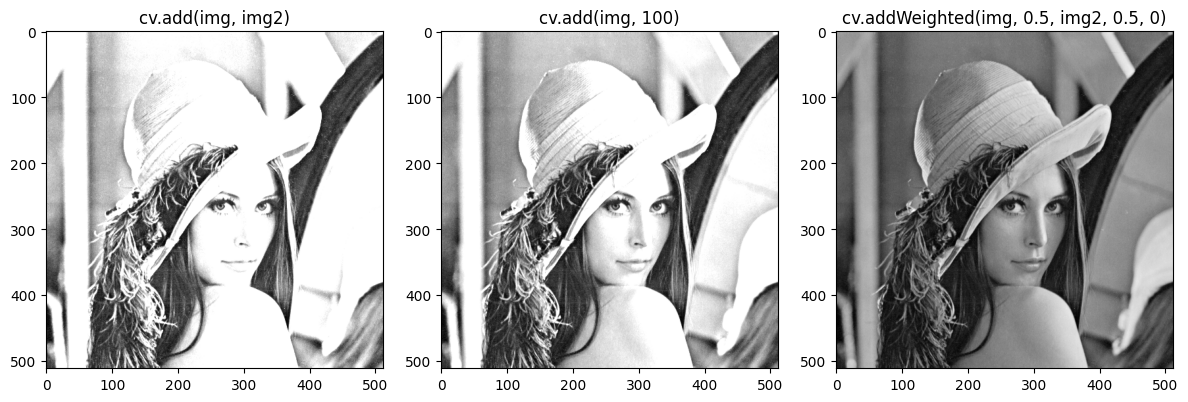

In [108]:
import cv2 as cv
import matplotlib.pyplot as plt

# lena 영상 읽기
img = cv.imread('lena512.tif', cv.IMREAD_GRAYSCALE)

# 예시용: 영상 자체 복사하여 두 번째 입력으로 사용
img2 = img.copy()

# 방법 1: 두 영상 단순 더하기 (cv.add는 오버플로 방지함)
add_result = cv.add(img, img2)

# 방법 2: 영상 + 상수 (밝기 증가)
bright_result = cv.add(img, 100)

# 방법 3: 가중치 기반 영상 합성
weighted_result = cv.addWeighted(img, 0.5, img2, 0.5, 0)

# 결과 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(add_result, cmap='gray')
plt.title('cv.add(img, img2)')

plt.subplot(1, 3, 2)
plt.imshow(bright_result, cmap='gray')
plt.title('cv.add(img, 100)')

plt.subplot(1, 3, 3)
plt.imshow(weighted_result, cmap='gray')
plt.title('cv.addWeighted(img, 0.5, img2, 0.5, 0)')

plt.tight_layout()
plt.show()


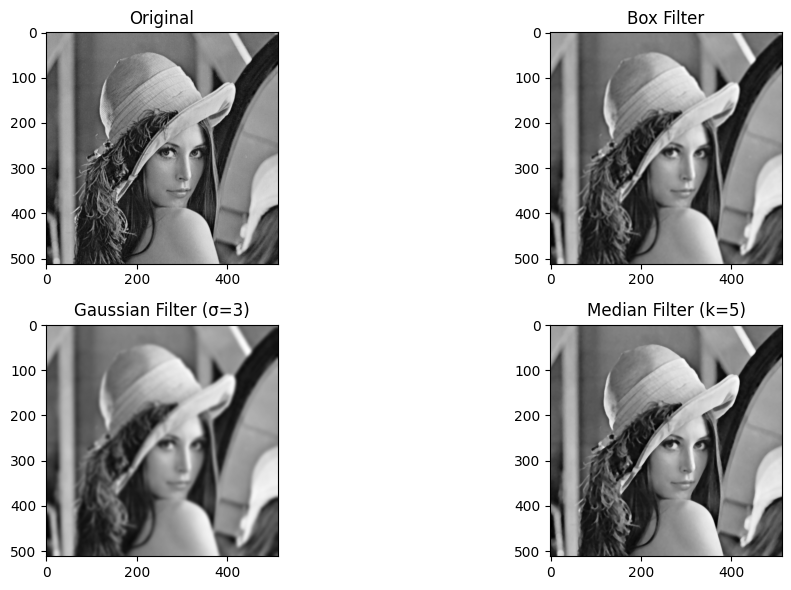

In [109]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 영상 불러오기 (Grayscale)
img = cv.imread('lena512.tif', cv.IMREAD_GRAYSCALE)

#  필터 종류(Blur 효과)	                특징                                        장점            	단점
#  평균(Box) 필터	        단순 평균, 성능은 빠르나 노이즈 제거 성능 낮음                빠르고 단순	        엣지 흐림, 세부 손실
#  가우시안 필터	             가중 평균, 노이즈 제거 효과 우수                    부드럽고 자연스러움	    계산 비용 약간 증가
#  미디안 필터	           가장자리 보존하며 노이즈 제거 (salt & pepper에 강함)     미디안 필터	잡음 제거에 탁월   성능 저하 가능성 있음

# ---------------------------------------------------------------

# 1. Box Filter (Averaging)
# 평균 필터(Box Filter 또는 Averaging Filter)는 이미지를 부드럽게(Smoothing) 만들어서 노이즈를 제거하는 데 사용되는 가장 기본적인 필터 중 하나

# 영상 처리에서 kernel(커널)은 필터링 또는 연산을 수행하기 위한 작은 행렬(또는 마스크)
kernel = np.ones((5, 5), np.float32) / 25   # 총 요소 수인 25로 나눔 -> 평균 필터링
box_filtered = cv.filter2D(img, -1, kernel) # kernel을 이용해 cv.filter2D를 적용한 결과 영상을 담고 있는 변수

# cv.filter2D()는 OpenCV에서 임의의 커널을 이용한 2D 컨볼루션 필터링을 수행하는 함수
# 쉽게 말해, 영상에 원하는 필터(커널)를 적용해서 새로운 영상을 생성할 때 사용하는 함수

# cv.filter2D(
#     src,          # 입력 영상
#     ddepth,       # 출력 영상 데이터 타입 (-1: 입력과 동일)
#     kernel        # 필터 커널 (예: 평균 필터, 엣지 검출 커널 등)
# )

# ---------------------------------------------------------------

# 2. Gaussian Filter (σ = 3 → w = 6*σ + 1 = 19)
# 가우시안 필터링(Gaussian Filtering)은 이미지에서 노이즈를 제거하고 부드럽게(smoothing) 만드는 데 사용되는 필터링 기법

sigma = 3 # σ: 표준편차 — 클수록 더 넓게 퍼짐 (→ 더 강한 블러 효과) | 얼마나 부드럽게 할지를 결정 (블러 강도)
w = int(6 * sigma + 1) # 가우시안 필터(Gaussian Filter)**를 적용할 때 사용하는 **커널 크기(kernel size)**를 계산하는 공식 -> w=int(6⋅σ+1)
gaussian_filtered = cv.GaussianBlur(img, (w, w), sigma)
# cv.GaussianBlur(
#     img,           # 입력 영상 (numpy 배열)
#     (w, w),        # 커널 크기 (가로, 세로) — 홀수만 가능
#     sigma          # 표준 편차 — 블러 강도 조절
# )

# ---------------------------------------------------------------

# 3. Median Filter (kernel size = 5)
# 미디안 필터(Median Filter)는 주변 픽셀의 중앙값(median)을 사용하여 현재 픽셀을 대체하는 비선형 필터

median_filtered = cv.medianBlur(img, 5)

# cv.medianBlur(
#     img,    # 입력 영상
#     5       # 커널 크기 (중앙값 필터의 창 크기) — 홀수만 가능: 커널 크기는 홀수(3, 5, 7, ...) 여야 하며, 너무 크면 경계까지 흐려짐
# )

# 결과 시각화
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')

plt.subplot(2, 2, 2)
plt.imshow(box_filtered, cmap='gray')
plt.title('Box Filter')

plt.subplot(2, 2, 3)
plt.imshow(gaussian_filtered, cmap='gray')
plt.title(f'Gaussian Filter (σ={sigma})')

plt.subplot(2, 2, 4)
plt.imshow(median_filtered, cmap='gray')
plt.title('Median Filter (k=5)')

plt.tight_layout()
plt.show()


In [110]:
# cv.Sobel(
#     src,         # 입력 영상 (보통 그레이스케일 영상)
#     ddepth,      # 출력 데이터 타입 (예: cv.CV_64F, cv.CV_8U 등)
#     dx,          # x 방향 미분 차수 (1이면 x 방향 에지 검출)
#     dy,          # y 방향 미분 차수 (1이면 y 방향 에지 검출)
#     ksize=3,     # Sobel 커널 크기 (1, 3, 5, 7 중 하나; 홀수만 가능)
#     scale=1,     # 미분 결과에 곱할 스케일 값 (기본값 1)
#     delta=0,     # 결과에 더할 값 (기본값 0)
#     borderType=cv.BORDER_DEFAULT  # 경계 처리 방식
# )

In [114]:
# lena512.tif 파일을 Grayscale 모드로 읽음 (Sobel 연산은 단일 채널에서 수행)
img = cv.imread('lena512.tif', cv.IMREAD_GRAYSCALE)

# ----------------------------------------------------------
# 방법 1: 출력 데이터 타입을 CV_8U로 설정하여 Sobel 연산 수행
# - CV_8U는 부호 없는 8비트 정수 (0~255만 표현 가능)
# - 음수 미분값은 0으로 잘려서 정보 손실이 발생할 수 있음
# ----------------------------------------------------------
sobelx_8u = cv.Sobel(img, ddepth=cv.CV_8U, dx=1, dy=0, ksize=5)  # X 방향 미분 (5x5 커널)
# Output dtype = cv.CV_8U
# cv.Sobel() 함수에서 ddepth = cv.CV_8U로 지정하면, **출력 영상이 8비트 정수형 (0~255)**으로 생성
# 이 방식은 간단하지만 에지 방향에 따른 음수 미분값은 잘려서 손실
# 예: 실제 미분 결과가 -150이면 → 0으로 바뀜
# 정밀도는 낮지만 빠르고 간단하게 에지를 볼 수 있음


# ----------------------------------------------------------
# 방법 2: CV_64F로 미분값을 정밀하게 계산한 뒤 절댓값을 취하고,
#        다시 CV_8U로 변환하여 표현 가능한 범위로 조정
# - 이 방식은 부호 있는 미분값(양수/음수)을 모두 보존 가능
# - 시각화를 위해 float → 절댓값 → 8비트로 변환
# ----------------------------------------------------------
sobelx_64f = cv.Sobel(img, ddepth=cv.CV_64F, dx=1, dy=0, ksize=5)    # X 방향 미분 (64비트 float)
sobelx_abs = np.absolute(sobelx_64f)                                # 미분 결과의 절댓값 계산
sobelx_8u_from_64f = np.uint8(np.clip(sobelx_abs, 0, 255))  
# Output dtype = cv.CV_64F. Then take its absolute and convert to cv.CV_8U
# ddepth = cv.CV_64F는 **출력을 64비트 부동소수점 형식(float64)**으로 설정
# 이 경우, 음수·소수 포함한 정확한 미분 결과를 모두 계산할 수 있음
# 이후 np.absolute()로 절댓값을 취하고, np.uint8()로 8비트 정수로 변환하여 화면에 표시 가능하게 만듬
# OpenCV는 화면에 출력할 때 0~255의 정수만 표현 가능하므로 변환이 필요함

In [115]:
# cv.imread('lena512.tif', cv.IMREAD_GRAYSCALE) vs gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
# ----------------------------------------------------
# 상황                          추천 방식              이유
# ----------------------------------------------------
# 처음부터 흑백 영상 처리만 할 경우     cv.IMREAD_GRAYSCALE    → 더 가볍고 빠름 (메모리 절약, 속도 향상)

# 이미지를 읽어올 때부터 Grayscale로 불러옴
# 이미지가 **1채널(gray)**로 메모리에 로드
# 불필요한 색상 정보를 아예 읽지 않기 때문에 메모리 절약이 가능하고 속도도 약간 빠름
# 단점: 컬러 정보가 필요하면 다시 불러와야 함 (컬러 복원이 불가능)

# 컬러 정보도 함께 써야 하는 경우      cv.cvtColor()           → 컬러 & 흑백 병행 처리 가능 (유연성 높음)

# 이미지를 **컬러(BGR)**로 불러온 다음, Grayscale로 변환
# 원본 컬러 이미지(img)를 그대로 보존하면서 Grayscale 버전(gray)을 별도로 생성할 수 있음
# 유연성 높음: 이후에도 컬러 기반 작업을 병행할 수 있음
# 단점: 메모리를 더 많이 사용하고, 변환 단계가 한 번 더 필요

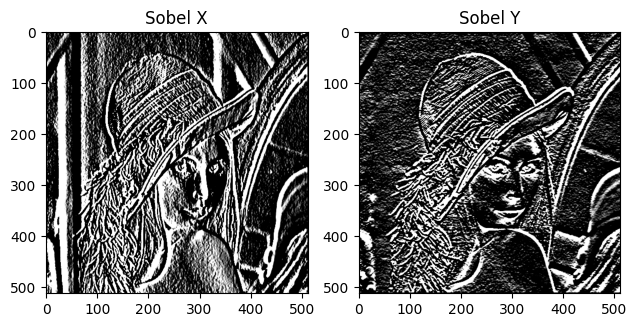

In [ ]:
# lena512.tif 영상을 불러옴 (컬러 이미지로 로드됨)
img = cv.imread('lena512.tif')

# 컬러 이미지를 그레이스케일로 변환
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# ksize(커널 크기)는 미분 필터의 크기와 민감도를 조절하는 역할
# 작은 커널 → 더 선명한 엣지, 하지만 노이즈 포함 가능
# 큰 커널 → 더 부드러운 엣지, 하지만 세부 에지 손실 가능
# ksize는 홀수만 가능: 1, 3, 5, 7, ...


# X 방향의 Sobel 에지를 계산합
# ddepth=-1: 출력 이미지의 깊이를 입력과 동일하게 설정
# dx=1, dy=0 → x 방향 미분 / ksize=5 → 커널 크기 5 사용
x_edges = cv.Sobel(gray, -1, 1, 0, ksize=5)
# 수직 구조물이 뚜렷하게 나타남
# Sobel X → 좌우 밝기 차를 검출
# 즉, X 축 방향(가로 방향)으로의 변화 → 수직 구조가 뚜렷하게 보임


# Y 방향의 Sobel 에지를 계산
# ddepth=-1: 출력 이미지의 깊이를 입력과 동일하게 설정
# dx=0, dy=1 → y 방향 미분 / ksize=5 → 커널 크기 5 사용
y_edges = cv.Sobel(gray, -1, 0, 1, ksize=5)
# 수평 구조물이 도드라짐
# Sobel Y → 상하 밝기 차를 검출
# 즉, Y 축 방향(세로 방향)으로의 변화 → 수평 구조가 뚜렷하게 보임

# 결과를 시각화
plt.subplot(1, 2, 1)                # 1행 2열 중 첫 번째 subplot
plt.imshow(x_edges, cmap='gray')   # x 방향 에지 표시
plt.title('Sobel X')

plt.subplot(1, 2, 2)                # 1행 2열 중 두 번째 subplot
plt.imshow(y_edges, cmap='gray')   # y 방향 에지 표시
plt.title('Sobel Y')

plt.tight_layout()                 # 레이아웃 자동 조절
plt.show()                         # 결과 화면에 출력

In [ ]:
# 📌 Canny 에지 검출 단계별 설명 및 각 단계의 목적
# ----------------------------------------------------------------------------
# 단계                          설명
# ----------------------------------------------------------------------------
# 1️⃣ Gaussian 블러
#   - 영상의 노이즈를 제거하고 부드럽게 만듦
#   - 목적: 잡음(노이즈)은 미분(에지 검출) 시 강하게 반응하므로,
#           이를 사전에 억제하여 잘못된 에지 검출을 방지함
#
# 2️⃣ 그래디언트 계산
#   - Sobel 연산을 이용해 X, Y 방향의 밝기 변화(미분)를 계산함
#   - 목적: 어떤 부분이 얼마나 급격히 변하는지를 수치화하여,
#           에지가 있는 위치를 감지할 수 있도록 함
#
# 3️⃣ 에지 강도 및 방향 계산
#   - Gradient magnitude (세기)와 방향(angle)을 계산
#   - 목적: 에지의 강도와 방향 정보를 기반으로 에지를
#           더 정확히 판별하고 정렬할 수 있도록 함
#
# 4️⃣ 비최대 억제 (Non-maximum suppression)
#   - 주변 픽셀 중 가장 강한 에지 픽셀만 남기고 나머지는 제거 → 얇은 에지 생성
#   - 목적: 두꺼운 에지가 생기지 않도록 하고,
#           가장 뚜렷한 에지 라인만 추출하기 위함
#
# 5️⃣ 이중 임계값 & 에지 추적
#   - 강한 에지(높은 임계값 이상)는 유지,
#     약한 에지는 강한 에지와 연결돼 있을 때만 유지
#   - 목적: 노이즈나 희미한 경계를 제거하고,
#           진짜 에지만 남기며 연결성을 유지하여 끊김 없이 추출함
#               왜 2개의 임계값을 쓰는가?
#                   하나만 쓰면 진짜 에지를 놓칠 수 있고, 거짓 에지를 포함할 수도 있음
#                       상한 임계값(T_high): 확실한 에지
#                       하한 임계값(T_low): 약하지만 연결된 경우 진짜일 수 있음
# ----------------------------------------------------------------------------
# cv.Canny(
#     image,         # 입력 영상 (보통 Grayscale)
#     threshold1,    # 하한 임계값 (T_low)
#     threshold2,    # 상한 임계값 (T_high)
#     apertureSize=3,# Sobel 연산에 사용될 커널 크기 (보통 3)
#     L2gradient=False  # True면 정확한 거리 기반 gradient 계산 사용
# )

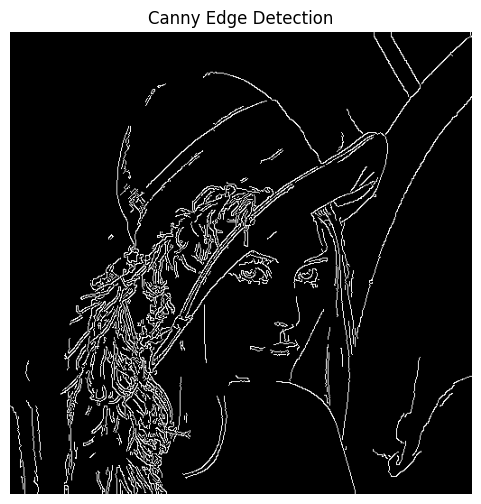

In [49]:
img = cv.imread('lena512.tif')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

edges = cv.Canny(img,100,200,3)

plt.figure(figsize=(6, 6))
plt.imshow(edges, cmap='gray')     # 에지는 이진 이미지 형태 (흑백)
plt.title('Canny Edge Detection')
plt.axis('off')
plt.show()

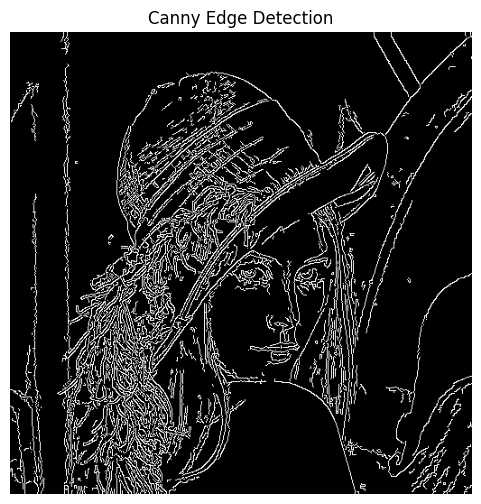

In [ ]:
# lena 영상 불러오기 (컬러)
img = cv.imread('lena512.tif')

# 그레이스케일로 변환
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Canny 에지 검출 수행: 이전과 다른 threshold 적용
edges = cv.Canny(gray, threshold1=50, threshold2=100, apertureSize=3)

# 결과 시각화
plt.figure(figsize=(6, 6))
plt.imshow(edges, cmap='gray')     # 에지는 이진 이미지 형태 (흑백)
plt.title('Canny Edge Detection')
plt.axis('off')
plt.show()


In [ ]:
# ✅ Canny 에지 검출 요약
# ------------------------------------------------------------
# - Canny 함수는 내부적으로 Gaussian smoothing(블러)을 수행함
#   (노이즈 억제 → 잘못된 에지 검출 방지)
#
# - threshold1 (T_low), threshold2 (T_high) 값에 따라
#   에지 검출의 민감도가 달라짐
#
#   ▶ threshold1이 너무 작으면:
#      → 작은 변화나 노이즈도 에지로 인식 (False Positive ↑)
#
#   ▶ threshold1이 너무 크면:
#      → 약한 진짜 에지를 놓침 (False Negative ↑)
#
#   ▶ threshold2가 너무 작으면:
#      → 너무 많은 픽셀이 강한 에지로 간주되어 에지가 복잡하게 나옴
#
#   ▶ threshold2가 너무 크면:
#      → 명확한 강한 에지 외엔 거의 검출되지 않음
#
# - Canny는 비최대 억제 및 이중 임계값 추적을 통해
#   얇고 연속된 에지를 효과적으로 검출하는 고성능 알고리즘임
# ------------------------------------------------------------

# 💡 참고: sigma(σ)를 조절하고 싶다면? 
# (Canny 함수에서 smoothing을 조절하려면 Gaussian convolution을 먼저 수행하고 Canny 함수를 호출해야 함)
# - Canny는 Gaussian smoothing을 자동 적용하므로,
#   sigma 값을 직접 지정할 수는 없음
# - 대신, Canny를 적용하기 전에 GaussianBlur를 수동으로 적용하면 됨

# # 예: sigma=1로 Gaussian 블러를 먼저 적용한 후 Canny 수행
# blurred = cv.GaussianBlur(gray, (5,5), sigmaX=1)  # 수동 Gaussian smoothing
# edges = cv.Canny(blurred, 50, 100)                # Canny 에지 검출 실행


In [ ]:
# =============================================================================
# ✅ 형태학적 연산(Morphological Operations)
# -----------------------------------------------------------------------------
# 형태학적 연산은 주로 **이진 영상**에 대해 적용되며,
# 영상 속 형태(shape), 구조(structure)를 다루는 연산
#
# ▶ 주 용도:
#   - 잡음 제거
#   - 경계 다듬기
#   - 빈 공간 메우기
#   - 객체 추출 및 분리
#
# 이 연산은 **구조 요소(Structuring Element)**를 사용하여,
# 이미지의 픽셀을 유지하거나 제거하는 방식으로 처리
# =============================================================================


# =============================================================================
# 🔍 주요 형태학적 연산과 그 의미
# -----------------------------------------------------------------------------
# 연산명     | 설명                      | 효과
# ---------- | ------------------------- | ----------------------------------
# Erosion    | 객체 외곽을 줄임          | 작은 노이즈 제거, 객체 축소
# Dilation   | 객체 외곽을 넓힘          | 구멍 메우기, 객체 확대
# Opening    | 침식 후 팽창              | 노이즈 제거, 세부 구조 보존
# Closing    | 팽창 후 침식              | 구멍 메우기, 경계 다듬기
# =============================================================================


# =============================================================================
# 🧠 작동 원리 
# -----------------------------------------------------------------------------
# - 연산 대상은 일반적으로 하얀 픽셀(255)이며
# - 구조 요소(Structuring Element)는 커널처럼 생긴 마스크
# - 이 마스크를 영상에 적용하여 조건에 따라 픽셀을 유지하거나 제거
# =============================================================================


# =============================================================================
# ✅ Structuring Element (구조 요소) 생성
# -----------------------------------------------------------------------------
# kernel = cv.getStructuringElement(shape, ksize, anchor)
#
# ▶ 인자 설명:
#   - shape  : 구조 요소의 형태 (cv.MORPH_RECT, MORPH_ELLIPSE, MORPH_CROSS 등)
#   - ksize  : 커널 크기 (예: (3, 3), (15, 15))
#   - anchor : 기준점 위치 (보통 생략하면 중앙 픽셀이 기준)
# =============================================================================


# =============================================================================
# ✅ 형태학적 연산 관련 OpenCV 함수 정리
# -----------------------------------------------------------------------------

# 🔸 침식 (Erosion)
# - 구조 요소 안에 완전히 포함되는 영역만 유지됨
# - 객체의 경계를 안쪽으로 깎음 → 객체 축소, 작은 노이즈 제거
# eroded = cv.erode(src, kernel, iterations=1)

# 🔸 팽창 (Dilation)
# - 구조 요소와 하나라도 겹치면 픽셀 유지
# - 객체의 경계를 바깥으로 확장 → 객체 연결, 구멍 메우기
# dilated = cv.dilate(src, kernel, iterations=1)

# 🔸 열기 (Opening)
# - 침식 후 팽창 (Erosion → Dilation)
# - 노이즈 제거에 효과적, 세부 구조 유지
# opened = cv.morphologyEx(src, cv.MORPH_OPEN, kernel)

# 🔸 닫기 (Closing)
# - 팽창 후 침식 (Dilation → Erosion)
# - 작은 구멍 메우기, 경계 다듬기
# closed = cv.morphologyEx(src, cv.MORPH_CLOSE, kernel)
# =============================================================================


# =============================================================================
# 📌 실습에서 사용하는 구조 요소 예시
# -----------------------------------------------------------------------------

# 15x15 타원형 커널
# kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (15, 15))

# 3x3 십자형 커널
# kernel = cv.getStructuringElement(cv.MORPH_CROSS, (3, 3))

# 3x3 사각형 커널
# kernel = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))
# =============================================================================


# =============================================================================
# ✅ 형태학적 연산의 쓰임 예시
# -----------------------------------------------------------------------------
# 작업 목적       | 사용할 연산
# ----------------|---------------------------
# 노이즈 제거     | Opening
# 구멍 메우기     | Closing
# 객체 분리       | Erosion
# 객체 확장       | Dilation
# 윤곽선 추출     | 원본 - Erosion 결과
# =============================================================================


---
실습 1

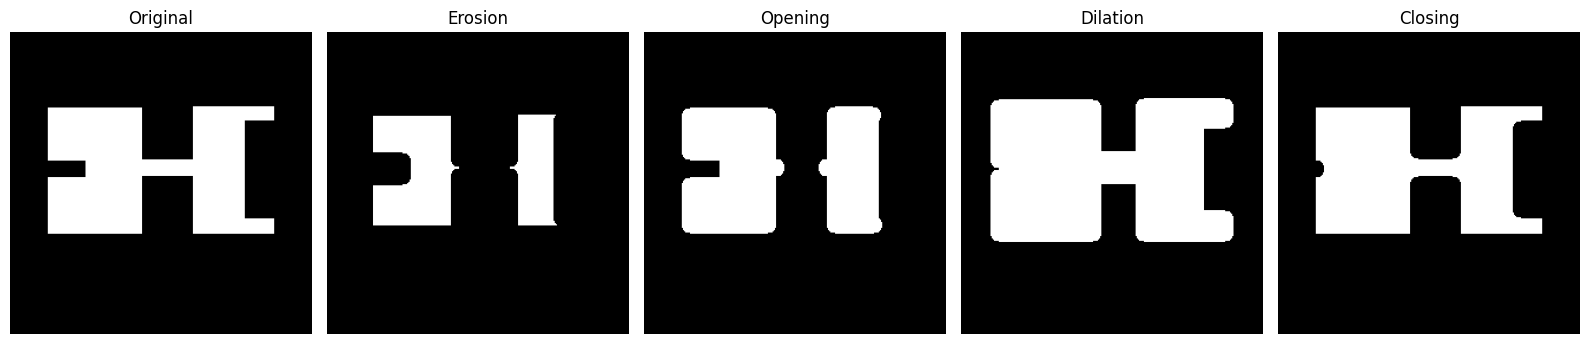

In [92]:
# 영상 불러오기 (흑백 모드)
gray = cv.imread('pattern.png', cv.IMREAD_GRAYSCALE)
# 구조 요소(Structuring Element) 설정: 15x15 타원형
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (15, 15))

# 침식(Erosion): 객체 축소, 노이즈 제거
eroded = cv.erode(gray, kernel, iterations=1)
# 팽창(Dilation): 객체 확장, 구멍 메우기
dilated = cv.dilate(gray, kernel, iterations=1)
# 열기(Opening): 침식 후 팽창 (작은 밝은 노이즈 제거용)
opened = cv.morphologyEx(gray, cv.MORPH_OPEN, kernel)
# 닫기(Closing): 팽창 후 침식 (작은 검은 구멍 메우기)
closed = cv.morphologyEx(gray, cv.MORPH_CLOSE, kernel)

# 결과 시각화
plt.figure(figsize=(16, 4))  # 1행 5열 플롯

plt.subplot(1, 5, 1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1, 5, 2)
plt.imshow(eroded, cmap='gray')
plt.title("Erosion")
plt.axis('off')

plt.subplot(1, 5, 3)
plt.imshow(opened, cmap='gray')
plt.title("Opening")
plt.axis('off')

plt.subplot(1, 5, 4)
plt.imshow(dilated, cmap='gray')
plt.title("Dilation")
plt.axis('off')

plt.subplot(1, 5, 5)
plt.imshow(closed, cmap='gray')
plt.title("Closing")
plt.axis('off')


plt.tight_layout()
plt.show()


---
실습 2

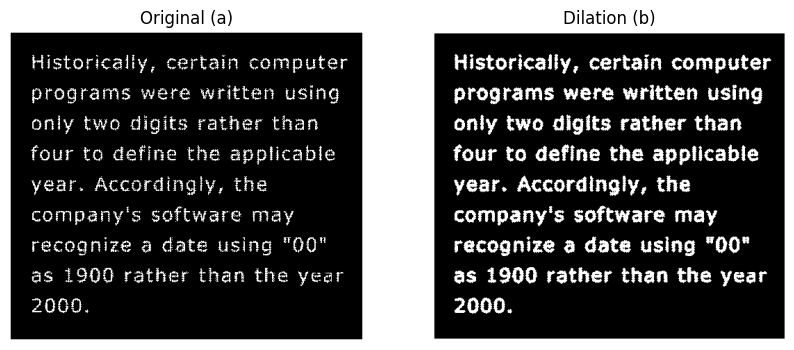

In [93]:
# '0907.png' 파일을 회색조로 읽음
img = cv.imread('0907.png', cv.IMREAD_GRAYSCALE)

# 구조 요소: 십자형 (3x3)
kernel = cv.getStructuringElement(cv.MORPH_CROSS, (3,3))

# Dilation (팽창) 연산 수행
dilated = cv.dilate(img, kernel, iterations=1)

# 원본과 팽창 결과 비교
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original (a)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(dilated, cmap='gray')
plt.title('Dilation (b)')
plt.axis('off')

plt.show()


---
실습 3

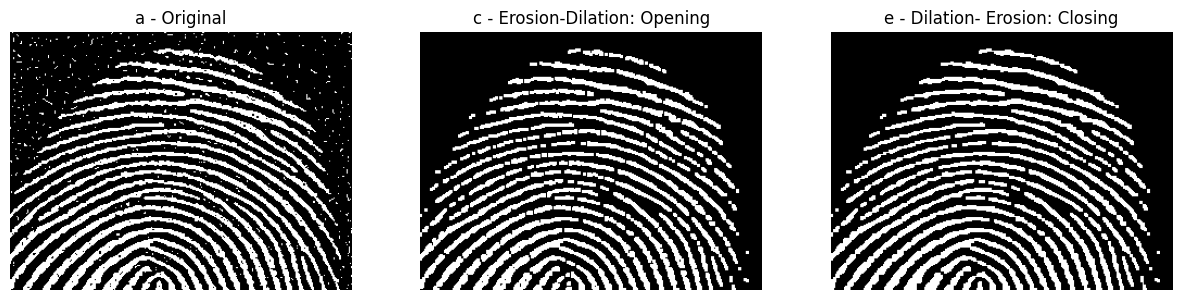

In [99]:
img = cv.imread('0911.png', cv.IMREAD_GRAYSCALE)

kernel = cv.getStructuringElement(cv.MORPH_RECT, (3,3))

# a: 원본 영상
a = img.copy()

# Erosion-Dilation-Dilation-Erosion 연산 수행
Erosion_1 = cv.erode(img, kernel, iterations=1)
Dilation_2 = cv.dilate(Erosion_1, kernel, iterations=1)

c = Dilation_2.copy() 

Dilation_3 = cv.dilate(Dilation_2, kernel, iterations=1)
Erosion_4 = cv.erode(Dilation_3, kernel, iterations=1)

e = Erosion_4.copy() 

# 결과 영상 디스플레이: a (원본), c (E-D-D-E), e (Closing 결과)
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(a, cmap='gray')
plt.title('a - Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(c, cmap='gray')
plt.title('c - Erosion-Dilation: Opening')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(e, cmap='gray')
plt.title('e - Dilation- Erosion: Closing')
plt.axis('off')

plt.show()

---
실습 4

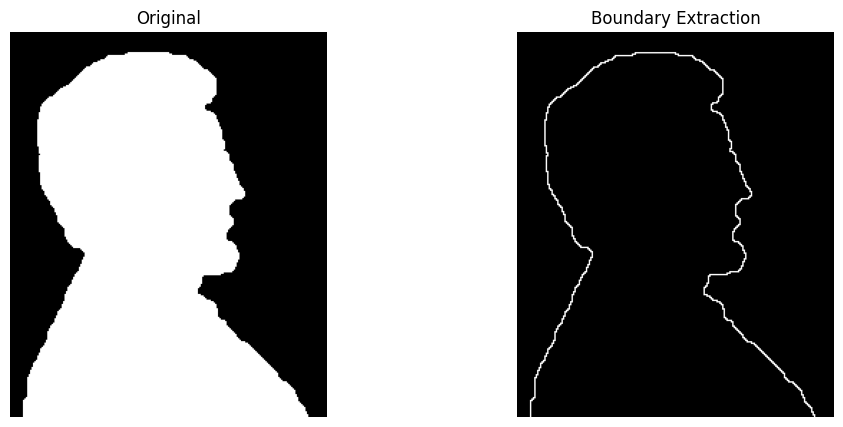

In [54]:
# '0914.png' 파일을 회색조로 읽음
img = cv.imread('0914.png', cv.IMREAD_GRAYSCALE)

# 구조 요소: 직사각형 (3x3)
kernel = cv.getStructuringElement(cv.MORPH_RECT, (3,3))

# Erosion 연산 수행
eroded = cv.erode(img, kernel, iterations=1)

# 원본 영상에서 erosion 결과를 빼서 경계 추출
boundary = cv.subtract(img, eroded)

# 결과 영상 디스플레이
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(boundary, cmap='gray')
plt.title('Boundary Extraction')
plt.axis('off')

plt.show()


---
과제2: 1

1. Sobel 에지 검출

본인이 촬영한 영상(크기를 800x800 이하로 조절)에 Sobel 에지 검출을 수행하고 소스 코드와 결과 영상을 제시. 

수평과 수직방향 에지 검출 결과와 gradient magnitude로 결합한 결과 영상을 제시.


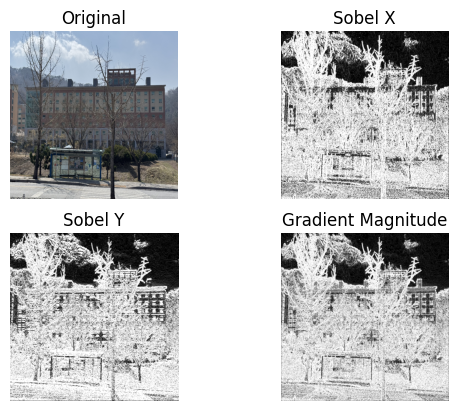

In [101]:
# 'lena512.tif' 파일을 읽고 회색조로 변환
img = cv.imread('HUFS.jpeg')

# 영상을 800x800 크기로 조절
resized_img = cv.resize(img, (800, 800))
gray = cv.cvtColor(resized_img, cv.COLOR_BGR2GRAY)

# 원본 영상을 BGR -> RGB로 변환 (matplotlib 디스플레이용)
img_rgb = cv.cvtColor(resized_img, cv.COLOR_BGR2RGB)

# Sobel 함수로 x, y 방향 에지 검출 (미분 연산)
sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=5)
sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=5)

# 절대값 및 8비트 변환
abs_sobelx = cv.convertScaleAbs(sobelx)
abs_sobely = cv.convertScaleAbs(sobely)

# 가중치 합으로 gradient magnitude 계산
gradient = cv.addWeighted(abs_sobelx, 0.5, abs_sobely, 0.5, 0)

# 결과 영상 디스플레이
plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(abs_sobelx, cmap='gray')
plt.title('Sobel X')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(abs_sobely, cmap='gray')
plt.title('Sobel Y')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(gradient, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.show()


---
과제2: 2

2. Canny 에지 검출

1번 영상에 대해 s = 1, 3, 5, 7로 변화시킨 Canny 에지 검출을 수행하고 소스 코드와 결과 영상을 제시. 

Threshold를 적절히 조절. 

s 를 조절하는 경우 Canny 함수를 호출하기 전에 Gaussian convolution을 먼저 해야 함.


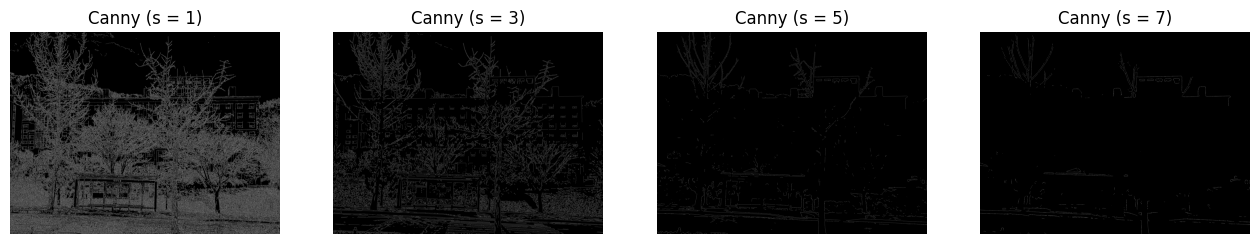

In [103]:
# 'lena512.tif' 파일을 회색조로 읽음
img = cv.imread('HUFS.jpeg', cv.IMREAD_GRAYSCALE)

# Gaussian smoothing 시 사용할 sigma 값 리스트
sigma_values = [1, 3, 5, 7]
edges_list = []

for s in sigma_values:
    # 커널 크기: w = 6*s + 1 (항상 홀수)
    w = int(6 * s + 1)
    blurred = cv.GaussianBlur(img, (w, w), s)
    
    # Canny 에지 검출; 임계값은 영상 특성에 맞게 조절 
    edges = cv.Canny(blurred, 20, 50)
    edges_list.append(edges)

# 결과 영상 디스플레이
plt.figure(figsize=(16,4))
for i, s in enumerate(sigma_values):
    plt.subplot(1,4,i+1)
    plt.imshow(edges_list[i], cmap='gray')
    plt.title(f'Canny (s = {s})')
    plt.axis('off')

plt.show()


---
과제2: 3

3. Canny edge에서 방향 검출

a. 256x256 크기 영상에서 중심이 (128, 128) 이고 반경이 80 픽셀인 원을 생성. 
배경의 색상은 50, 원의 색상은 200으로 지정.

b. s = 1 인 Canny 방식으로 에지를 검출

c. 각 에지점의 방향을 검출하는 기능을 추가하여 각도가 30도 ~ 60도 인 픽셀들만 검출하여 디스플레이 함

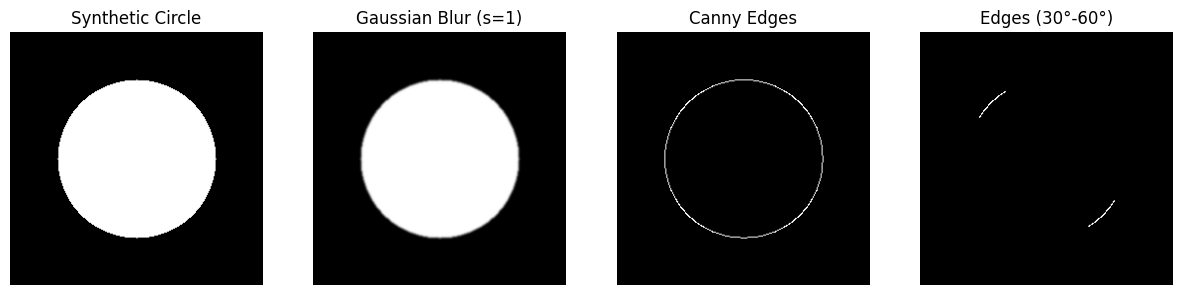

In [ ]:
# a. 256x256 영상 생성: 배경은 50(모든 픽셀 값을 50으로 초기화)

# np.full(shape, value, dtype): 지정한 값으로 배열을 채움
img = np.full((256,256), 50, dtype=np.uint8)
# 중심이 (128, 128), 반지름이 80인 원을 그림
# 색상 값은 200 (밝은 회색)으로 채움
# -1은 내부를 꽉 채우겠다는 의미 (채우기 모드)
# 즉, 어두운 배경 위에 밝은 원을 그리는 셈
cv.circle(img, (128,128), 80, 200, -1)  # 채워진 원 그리기

# b. Gaussian smoothing (sigma=1, 커널 크기: 6*1+1 = 7)
blurred = cv.GaussianBlur(img, (7,7), 1)

# c. Canny 에지 검출 (임계값은 예시로 50, 150 사용)
edges = cv.Canny(blurred, 50, 150)

# gradient 방향 계산을 위해 Sobel 연산 적용
grad_x = cv.Sobel(np.float32(blurred), cv.CV_64F, 1, 0, ksize=3)
grad_y = cv.Sobel(np.float32(blurred), cv.CV_64F, 0, 1, ksize=3)

# 각도 계산 (degree 단위, 0~180 범위로 변환)

# grad_y와 grad_x는 각각 Y 방향, X 방향 그래디언트(Sobel 결과)
# arctan2(grad_y, grad_x): 각 점에서의 기울기 방향(라디안 단위) 계산
# np.degrees(): 라디안 값을 도(degree)로 변환 (0~180 또는 0~360 범위)
angles = np.degrees(np.arctan2(grad_y, grad_x))
# np.mod(angles, 180): 각도를 0~180도 범위로 정규화
# (180도 이상의 방향은 에지 방향상 0~180도 안에서 반복되므로 동일하게 처리함)
angles = np.mod(angles, 180)

# 에지 픽셀 중 각도가 30°~60°인 픽셀 선택
mask = (edges > 0) & (angles >= 30) & (angles <= 60)
selected_edges = np.zeros_like(img)
selected_edges[mask] = 255

# 결과 영상 디스플레이
plt.figure(figsize=(15,4))
plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title('Synthetic Circle')
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(blurred, cmap='gray')
plt.title('Gaussian Blur (s=1)')
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(selected_edges, cmap='gray')
plt.title('Edges (30°-60°)')
plt.axis('off')

plt.show()
